In [1]:
import json
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt


def gather_results(results_folder, epochs=None, runs=None):
    """Load pretraining results from results/pretraining/seed_N/."""

    all_files = []
    for root, dirs, files in os.walk(results_folder):
        for fname in files:
            if fname.endswith('.json') and 'config' not in fname:
                all_files.append(os.path.join(root, fname))

    all_rows = []
    for f in all_files:
        with open(f) as fh:
            d = json.load(fh)

        # run number from filename: results_1.json -> run=1
        m = re.search(r'results_(\d+)\.json', os.path.basename(f))
        d['run'] = int(m.group(1)) if m else -99

        all_rows.append(d)

    if not all_rows:
        raise ValueError("No results - check settings")

    final_df = pd.DataFrame(all_rows)

    if epochs is not None:
        final_df = final_df[final_df['num_epochs'].isin(epochs)]
    if runs is not None:
        final_df = final_df[final_df['run'].isin(runs)]

    if final_df.empty:
        raise ValueError("No results after filtering - check settings")

    return final_df


def results_barchart(final_df):
    """Bar chart of train_acc and test_acc grouped by number of training epochs."""

    df_melted = final_df.melt(
        id_vars=['num_epochs'],
        value_vars=['train_acc', 'test_acc'],
        var_name='Metric',
        value_name='Accuracy'
    )
    df_melted['Metric'] = df_melted['Metric'].str.replace('_', ' ').str.capitalize()

    plt.clf()
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    g = sns.barplot(
        data=df_melted,
        x='num_epochs',
        y='Accuracy',
        hue='Metric',
        errorbar='sd',
        capsize=.1,
        palette=['#1f77b4', '#ff7f0e']
    )

    stats = df_melted.groupby(['num_epochs', 'Metric'])['Accuracy'].agg(['mean', 'std']).reset_index()

    for container in g.containers:
        labels = []
        for i, bar in enumerate(container):
            height = bar.get_height()
            if height > 0:
                stat_row = stats.iloc[i]
                label = f"{height:.2f}\n({stat_row['std']:.2f})"
                labels.append(label)
            else:
                labels.append("")
        g.bar_label(container, labels=labels, padding=5, fontsize=11)

    plt.title("Training and Test Accuracy, by Number of Training Epochs")
    plt.xlabel("Number of Training Epochs")
    plt.ylabel("Accuracy")
    plt.legend(title="Metric Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 115)
    plt.show()

<Figure size 640x480 with 0 Axes>

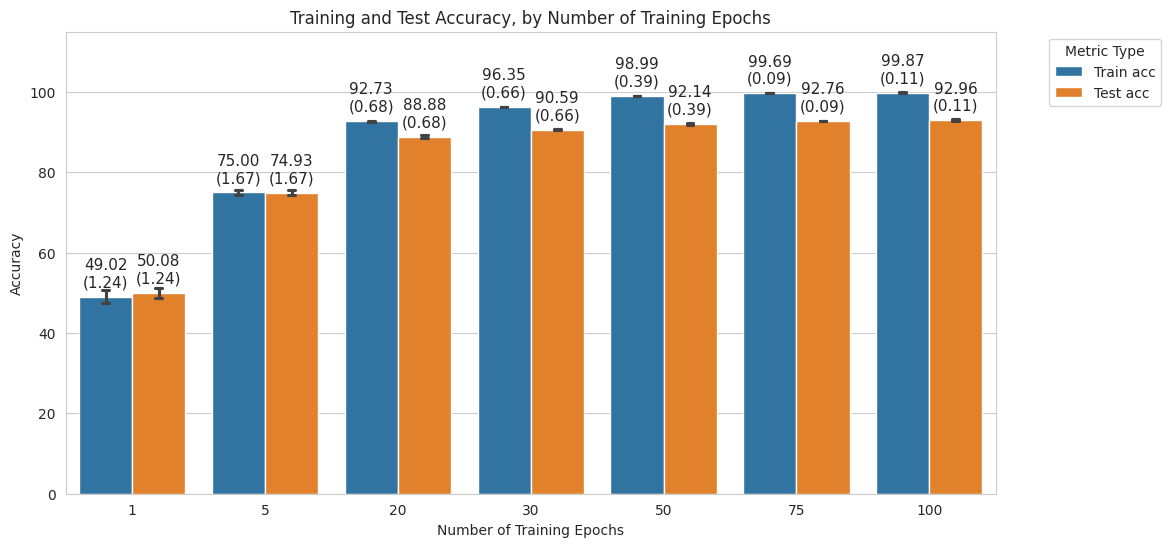

In [2]:
results = gather_results("results/pretraining/seed_4")
# results["test_acc"] = results["test_acc"].astype(float)
results_barchart(results)